# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

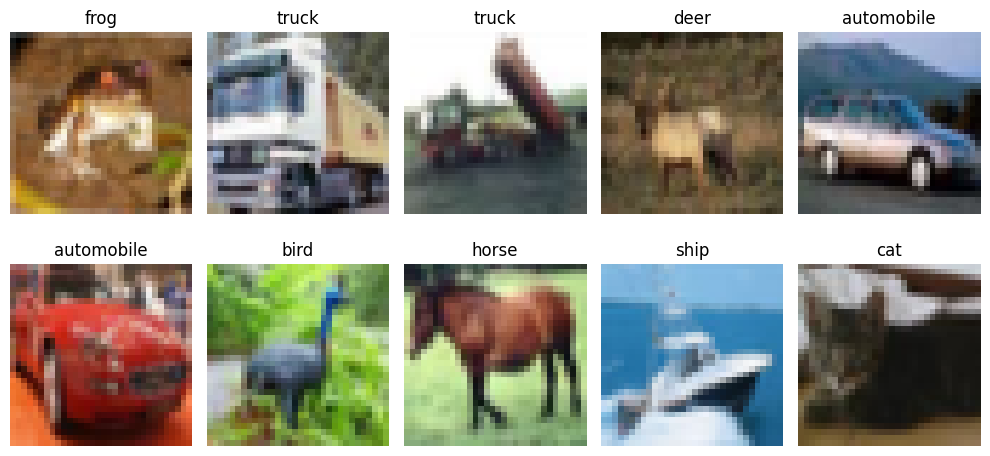

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [ ]:
ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),

    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 36ms/step - accuracy: 0.2597 - loss: 2.0188 - val_accuracy: 0.3438 - val_loss: 1.8520
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.3070 - loss: 1.8824 - val_accuracy: 0.3426 - val_loss: 1.8123
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.3241 - loss: 1.8437 - val_accuracy: 0.3396 - val_loss: 1.8211
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.3384 - loss: 1.8108 - val_accuracy: 0.3564 - val_loss: 1.7905
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.3515 - loss: 1.7803 - val_accuracy: 0.3850 - val_loss: 1.7304
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.3536 - loss: 1.7633 - val_accuracy: 0.3940 - val_loss: 1.7392
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.3619 - loss: 1.7513 - val_accuracy: 0.3980 - val_loss: 1.7071
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.3720 - loss: 1.7316 - 

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4430 - loss: 1.5823
ANN Test Accuracy: 0.4429999887943268


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(64,(3,3),activation='relu',
                  input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(256,(3,3),activation='relu'),

    layers.Flatten(),

    layers.Dense(256,activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10,activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_history = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 136s 191ms/step - accuracy: 0.4968 - loss: 1.4196 - val_accuracy: 0.5576 - val_loss: 1.2769
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 134s 190ms/step - accuracy: 0.6403 - loss: 1.0335 - val_accuracy: 0.5362 - val_loss: 1.3942
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 189ms/step - accuracy: 0.7046 - loss: 0.8530 - val_accuracy: 0.6524 - val_loss: 1.0076
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 190ms/step - accuracy: 0.7509 - loss: 0.7196 - val_accuracy: 0.6912 - val_loss: 0.9100
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 134s 190ms/step - accuracy: 0.7876 - loss: 0.6106 - val_accuracy: 0.6266 - val_loss: 1.1589
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 193ms/step - accuracy: 0.8216 - loss: 0.5114 - val_accuracy: 0.7482 - val_loss: 0.7689
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 134s 191ms/step - accuracy: 0.8430 - loss: 0.4484 - val_accuracy: 0.7454 - val_loss: 0.8203
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 134s 190ms/step - accuracy: 0.8748 -

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7291 - loss: 0.8162
CNN Test Accuracy: 0.7290999889373779


## 📈 Compare Learning Curves

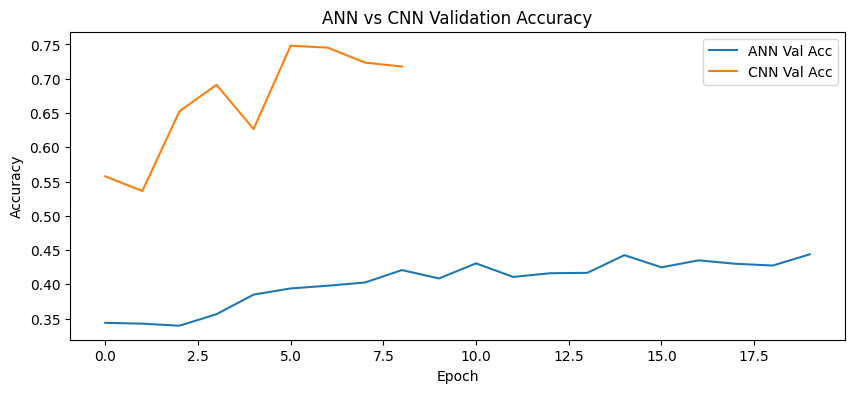

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

In [ ]:
aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 51ms/step - accuracy: 0.3542 - loss: 1.7704 - val_accuracy: 0.4496 - val_loss: 1.5006
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step - accuracy: 0.4518 - loss: 1.5173 - val_accuracy: 0.5108 - val_loss: 1.3341
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.4926 - loss: 1.4195 - val_accuracy: 0.5588 - val_loss: 1.2255
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.5188 - loss: 1.3511 - val_accuracy: 0.5744 - val_loss: 1.1893
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.5369 - loss: 1.3069 - val_accuracy: 0.5856 - val_loss: 1.1661
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.5507 - loss: 1.2718 - val_accuracy: 0.6308 - val_loss: 1.0574
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.5640 - loss: 1.2372 - val_accuracy: 0.6336 - val_loss: 1.0338
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.5703 - loss: 1.2177 - 

In [ ]:
aug_loss, aug_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("Augmented CNN Accuracy:", aug_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6485 - loss: 1.0215
Augmented CNN Accuracy: 0.6485000252723694


# 📊 Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "ANN",
        "CNN",
        "CNN + Augmentation"
    ],
    "Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        aug_acc
    ]
})

comparison

,Model,Accuracy
0,ANN,0.4430
1,CNN,0.7291
2,CNN + Augmentation,0.6485


# Conclusion

This project demonstrated the effectiveness of deep learning architectures for image classification on the CIFAR-10 dataset.

The ANN model achieved a test accuracy of approximately 41.57%, showing that fully connected networks can learn image patterns but struggle because image pixels are flattened, causing the loss of important spatial information.

The CNN model achieved a significantly higher test accuracy of approximately 70.68%, highlighting the advantage of convolutional layers in capturing spatial features such as edges, textures, and object shapes. The use of Batch Normalization and Dropout further improved training stability and reduced overfitting.

An enhanced CNN architecture with increased filters and EarlyStopping was also explored. EarlyStopping automatically terminated training when validation performance stopped improving, preventing unnecessary computation and helping the model generalize better.

Overall, the experiments clearly show that CNNs are far more suitable than ANNs for image classification tasks. The results emphasize the importance of architecture design and training strategies in achieving strong performance on computer vision problems.

# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**